Apply appropriate ML algorithm on a dataset collected in a cosmetics shop showing      

details of customers to predict customer response for special offer. Create confusion  
matrix based on above data and find


Accuracy

Precision

Recall

F-1 score

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


data = {
    "Age": [18, 21, 25, 30, 35, 40, 22, 28, 45, 50, 27, 33],
    "Product": [
        "Lipstick", "Face Wash", "Foundation", "Perfume",
        "Sunscreen", "Anti-Aging Cream", "Lipstick", "Face Wash",
        "Perfume", "Anti-Aging Cream", "Sunscreen", "Foundation"
    ],
    "Buy": [1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
}

df = pd.DataFrame(data)

print(df)

    Age           Product  Buy
0    18          Lipstick    1
1    21         Face Wash    1
2    25        Foundation    0
3    30           Perfume    1
4    35         Sunscreen    1
5    40  Anti-Aging Cream    0
6    22          Lipstick    1
7    28         Face Wash    0
8    45           Perfume    1
9    50  Anti-Aging Cream    1
10   27         Sunscreen    0
11   33        Foundation    1


By using DataFrame

In [ ]:
df = pd.get_dummies(df, columns=["Product"])
print(df)

    Age  Buy  Product_Anti-Aging Cream  Product_Face Wash  Product_Foundation  \
0    18    1                     False              False               False   
1    21    1                     False               True               False   
2    25    0                     False              False                True   
3    30    1                     False              False               False   
4    35    1                     False              False               False   
5    40    0                      True              False               False   
6    22    1                     False              False               False   
7    28    0                     False               True               False   
8    45    1                     False              False               False   
9    50    1                      True              False               False   
10   27    0                     False              False               False   
11   33    1                

In [ ]:
X = df.drop("Buy", axis=1)
y = df["Buy"]

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Predictions:", y_pred)

Predictions: [1 0 1 0]


In [ ]:

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[0 1]
 [2 1]]


In [ ]:

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.25
Precision: 0.5
Recall   : 0.3333333333333333
F1 Score : 0.4


Analysis with dataset

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

data = pd.read_csv("/content/cosmetic.csv")
print(data.head())
print(data.info())
print(data.describe())

   CustomerID  Age  Gender  Annual_Income Location_Type  Total_Spent  \
0        1001   56  Female          87846         Urban       766.33   
1        1002   46    Male          37540         Rural       311.61   
2        1003   32  Female         125432         Urban      1710.71   
3        1004   24  Female          54231      Suburban       476.44   
4        1005   68    Male          61329         Rural       410.69   

   Purchase_Frequency  Last_Purchase_Days  Avg_Order_Value  Email_OptIn  \
0                   5                  17           153.27            1   
1                   9                  98            34.62            0   
2                  14                   3           122.19            1   
3                   6                  45            79.41            1   
4                   4                 120           102.67            0   

   Num_Web_Visits  Response  
0               6         1  
1               3         0  
2              12         

In [ ]:
data = data.drop("CustomerID", axis=1)

In [ ]:
data.isnull().value_counts()

,,,,,,,,,,,count
Age,Gender,Annual_Income,Location_Type,Total_Spent,Purchase_Frequency,Last_Purchase_Days,Avg_Order_Value,Email_OptIn,Num_Web_Visits,Response,
False,False,False,False,False,False,False,False,False,False,False,500


In [ ]:
data.isnull().sum()

,0
Age,0
Gender,0
Annual_Income,0
Location_Type,0
Total_Spent,0
Purchase_Frequency,0
Last_Purchase_Days,0
Avg_Order_Value,0
Email_OptIn,0
Num_Web_Visits,0


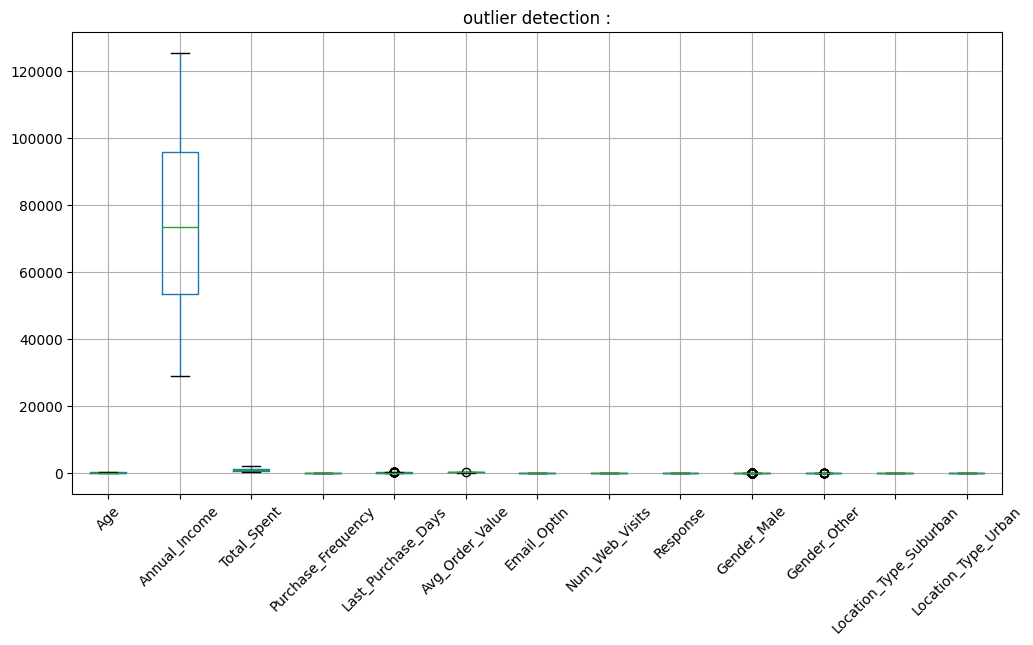

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12,6))
data.boxplot()
plt.title("outlier detection :")
plt.xticks(rotation=45)
plt.show()

In [ ]:
data.columns = data.columns.str.strip()
print(data.columns)

Index(['Age', 'Gender', 'Annual_Income', 'Location_Type', 'Total_Spent',
       'Purchase_Frequency', 'Last_Purchase_Days', 'Avg_Order_Value',
       'Email_OptIn', 'Num_Web_Visits', 'Response'],
      dtype='object')


In [ ]:
X = data.drop("Response", axis=1)
y = data["Response"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (500, 10)
Target shape: (500,)


In [ ]:
data = pd.get_dummies(data, drop_first=True)

In [ ]:
x=data.drop("Response",axis=1)
y=data["Response"]

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [ ]:
y_model=model.predict(x_test)

In [ ]:
cm = confusion_matrix(y_test, y_model)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[47  1]
 [ 4 48]]


In [ ]:
accuracy = accuracy_score(y_test,y_model )
precision = precision_score(y_test, y_model)
recall = recall_score(y_test, y_model)
f1 = f1_score(y_test, y_model)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.95
Precision: 0.9795918367346939
Recall: 0.9230769230769231
F1 Score: 0.9504950495049505


Calculating Values By Using User-Defined Functions

In [ ]:
TN = cm[0][0]
FP = cm[0][1]
FN = cm[1][0]
TP = cm[1][1]

print("TN:", TN)
print("FP:", FP)
print("FN:", FN)
print("TP:", TP)

TN: 47
FP: 1
FN: 4
TP: 48


In [ ]:
def my_accuracy(TN,FP,FN,TP):
  return (TP+TN)/(TP+TN+FP+FN)

In [ ]:
def my_precision(TP,FP):
  return  TP/(TP+FP)

In [ ]:
def my_recall(TP,FN):
  return TP/(TP+FN)

In [ ]:
def my_f1(TP, FP, FN):
    precision = my_precision(TP, FP)
    recall = my_recall(TP, FN)
    return 2 * precision * recall / (precision + recall)

In [ ]:
acc = my_accuracy(TP, TN, FP, FN)
prec = my_precision(TP, FP)
rec = my_recall(TP, FN)
f1 = my_f1(TP, FP, FN)

print("User Defined Accuracy:", acc)
print("User Defined Precision:", prec)
print("User Defined Recall:", rec)
print("User Defined F1 Score:", f1)

User Defined Accuracy: 0.52
User Defined Precision: 0.9795918367346939
User Defined Recall: 0.9230769230769231
User Defined F1 Score: 0.9504950495049506


In [ ]:


X_age = data[['Age']]
y = data['Response']

model_age = LogisticRegression()
model_age.fit(X_age, y)

LogisticRegression()

In [ ]:
age_range=np.linspace(data['Age'].min(),data['Age'].max(),300)
age_range=age_range.reshape(-1,1)

In [ ]:
probabilities=model_age.predict_proba(age_range)[:,1]

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


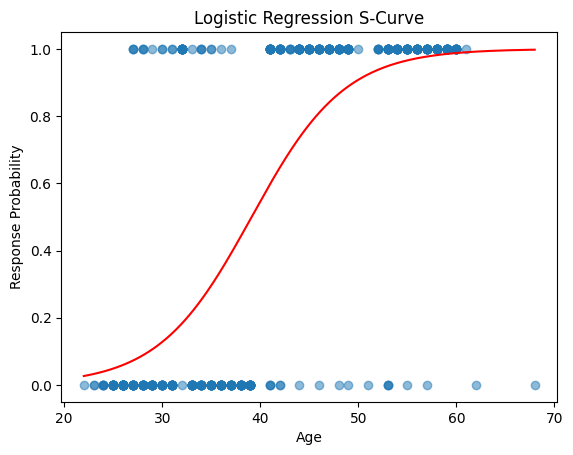

In [ ]:
plt.figure()

plt.scatter(data['Age'], data['Response'], alpha=0.5)
plt.plot(age_range, probabilities, color='red')

plt.xlabel('Age')
plt.ylabel('Response Probability')
plt.title('Logistic Regression S-Curve')

plt.show()